In [1]:
!pip install replay-rec --quiet
!pip install implicit --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.8/196.8 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.9/235.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.6/390.6 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.5/290.5 kB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2024.8.0 requires dask==2024.8.0, but you have dask 2024.12.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 69.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import mean_absolute_error
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
import scipy.sparse as sparse
import scipy
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

from replay.metrics import Experiment
import implicit # для ALS
from datasets import load_dataset
import matplotlib.pyplot as plt

## **1 ▎Модели матричной факторизации**

**Задание**

- Выберите любой понравившийся вам набор данных с количеством рейтингов более 1М по ссылке: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023
- Проведите базовый EDA - распределения рейтингов, количество уникальных товаров и т.д. При необходимости фильтруйте данные.
- Сделайте разбиение данных на train и test методом leave-one-out.
- На основании вашего датасета постройте 3-4 рекомендательных модели. Можно включить простой бейзлайн типа модели, рекомендующей самые популярные товары, а также использовать библиотеку implicit и другие.
- Оцените качество полученных рекомендаций по метрикам HR@10, MRR@10, NDCG@10, coverage.
- Напишите выводы о проделанной работе: качество какой модели оказалось лучше, почему.

## **2 ▎Датасет прграммного обеспечения**

### ▎**Датасет взаимодействии**

Для датасета, загружаем данные по взаимодейстию покупателя с товарами програмного обеспечения

In [3]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", 
                       "raw_review_Software", 
                       trust_remote_code=True)
dataset_df = dataset['full'].to_pandas()

# We can immediately convert the timestamp in millisecond format into datatime format
dataset_df['timestamp'] = pd.to_datetime(dataset_df['timestamp'], unit='ms')

# drop columns we won't be using
dataset_df.drop(['title','text','images','helpful_vote','verified_purchase'],axis=1,inplace=True)
dataset_df = dataset_df.rename(columns={'parent_asin':'item_id'})

README.md:   0%|          | 0.00/30.3k [00:00<?, ?B/s]

Amazon-Reviews-2023.py:   0%|          | 0.00/39.6k [00:00<?, ?B/s]

Software.jsonl:   0%|          | 0.00/1.87G [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

In [4]:
# check for duplicates
dataset_df[['user_id','item_id','timestamp']].value_counts()

user_id                       item_id     timestamp              
AGALPU5ARZEK75CGKYELK232AHGA  B06XP4F49R  2019-01-23 22:01:29.630    27
AE3QHFBC2YC4YRQJZWSP2Z7LUVNA  B00BJ4ETBW  2015-04-25 07:45:40.000    11
AHK7CJWVLIXTRDTPJ5ZEEL56UCVA  B01LXOU5PM  2018-09-26 00:17:44.554    10
AGCHXQUQ54YTXOGYRWFSV4MQFMQA  B00O109QX2  2018-04-08 15:37:17.347    10
AGNGFKMPODAP7XWAGIC42WCSGBMQ  B00IG2DOKM  2016-08-18 13:08:27.000    10
                                                                     ..
AFEUXIC24P7FP4T6M6M5CZO33NKQ  B00DVKOYBM  2015-09-07 20:33:11.000     1
AFEUXHN4I3PIA6WYZQT2SEJUSXWA  B00XGNNN52  2017-07-29 18:00:39.829     1
                              B0081JPTXK  2013-04-03 18:31:55.000     1
                              B007TBAQCK  2016-07-23 16:24:17.000     1
AHZZZYHANWL2OW5PGXDOBUTJXCTA  B07RCG9SRL  2020-04-23 04:02:34.597     1
Name: count, Length: 4829120, dtype: int64

In [5]:
dataset_df.drop_duplicates(subset=['user_id','item_id','timestamp'],inplace=True)

### ▎**Датасет товаров**

- `parent_asin` : идентификатор (программное обеспечение) товара
- `user_id` : Идентификатор Пользователь

In [6]:
meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", 
                    "raw_meta_Software",
                    trust_remote_code=True)
ldf = meta["full"].to_pandas()
ldf = ldf.rename(columns={'parent_asin':'item_id'})
ldf.drop(['features','description','images','videos','details',
          'bought_together','subtitle','author','categories'],axis=1,inplace=True)
ldf = ldf[~(ldf['price'] == 'None')]
ldf['price'] = ldf['price'].astype('float')
ldf.head()

meta_Software.jsonl:   0%|          | 0.00/256M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

,main_category,title,average_rating,rating_number,price,store,item_id
0,Appstore for Android,Accupressure Guide,3.6,NaN,0.00,mAppsguru,B00VRPSGEO
1,Appstore for Android,Ankylosaurus Fights Back - Smithsonian's Prehi...,4.0,NaN,2.99,"Oceanhouse Media, Inc",B00NWQXXHQ
2,Appstore for Android,Mahjong 2015,3.1,NaN,0.00,sophiathach,B00RFKP6AC
3,Appstore for Android,Jewels Brick Breakout,4.2,NaN,0.00,Bad Chicken,B00SP2QU0E
4,Appstore for Android,Traffic Police: Off-Road Cub,3.3,NaN,0.00,Dast 2 For Metro,B01DZIT64O


## **3 ▎Разведовательный анализ**

<Axes: >

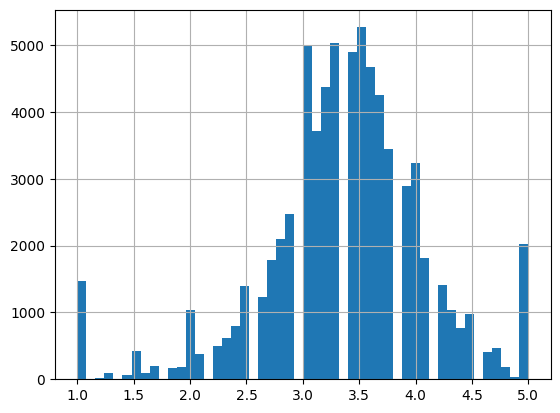

In [7]:
# Среднее рейтинга товара
ldf.average_rating.hist(bins=50)

(0.0, 100.0)

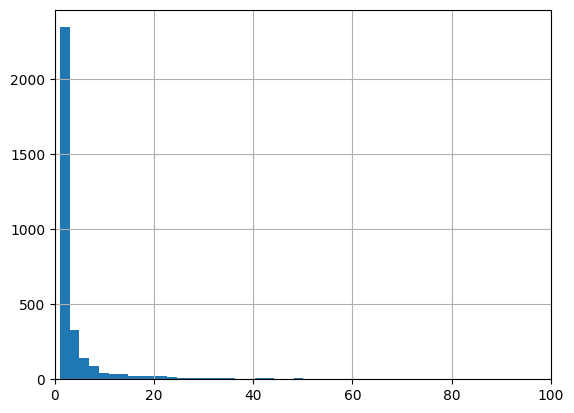

In [8]:
# Среднее количество ретингов
ldf.rating_number.value_counts().hist(bins=3000)
plt.xlim(0,100)

In [9]:
df = dataset_df.copy()

In [10]:
# main category
ldf['main_category'].value_counts()

main_category
Appstore for Android    67849
Software                 2922
Home Audio & Theater        1
Computers                   1
Name: count, dtype: int64

(0.0, 100.0)

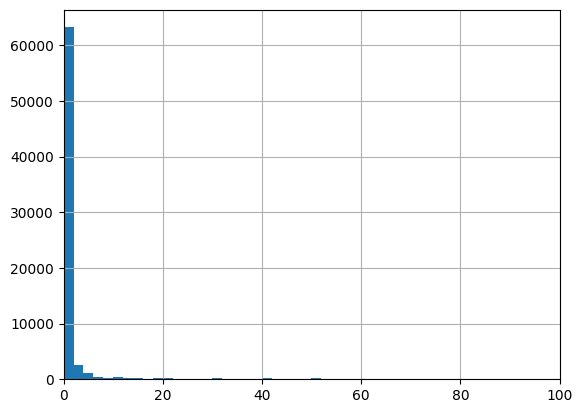

In [11]:
ldf['price'].hist(bins=1000)
plt.xlim(0,100)

## **4 ▎Предобработка**

### Фильтрация данных по признаку фичей

Отфильтруем по колонкам признаков фичей:
- `average_price` : Средний рейтинг товара
- `rating_number` : Количество отзывов


Оставляем только взамидействии пользователей с этими товарами, остальные удаляем

In [12]:
'''

Фильтрация по фичам [ldf]

'''

print('Количество взаимодействии в исходной выборке ',df.shape[0])
print('Количество товаров в исходной выборке ',ldf.shape[0])
# Количество товаров в исходной выборке

# Средний рейтинг тована > 3.5
# Количество рейтингов > 50 раз
ldf = ldf[(ldf['average_rating'] >= 4.0) & (ldf['rating_number'] > 500)]

df = df[df['item_id'].isin(ldf['item_id'])]
print('Количество взаимодействии после фильтрации ',df.shape[0])
print('Количество товаров после фильтрации ',ldf.shape[0])

Количество взаимодействии в исходной выборке  4829120
Количество товаров в исходной выборке  70985
Количество взаимодействии после фильтрации  1545391
Количество товаров после фильтрации  1487


### Фильтрация данных по взаимодействиям

Фильруем по данным взаимодействии пользователей и товаром:
- фильтруем пользователей у которых мало взаимодейсвии
- фильтруем товары которых мало покупали

In [13]:
'''

Фильтрации по взаимодействиям [df]

'''

# Количество взаимодействии для пользователя
user_counts = df['user_id'].value_counts()

# Пользователи у которых больше n пользователей
user_count_limit_users = user_counts[user_counts > 15].index
df = df[df['user_id'].isin(user_count_limit_users)]
print('Количество взаимодействии после фильтрации ',df.shape[0])


# Товары которыйх покупали мельше n раз
item_counts = df['item_id'].value_counts()
df = df[~df['item_id'].isin(item_counts[item_counts < 30].index)]
print('Размер датасета после фильтрации товаров: ',df.shape[0])

Количество взаимодействии после фильтрации  18837
Размер датасета после фильтрации товаров:  14047


### Расспределение рейтингов

In [14]:
df['rating'].value_counts(normalize=True)*100

rating
5.0    60.596569
4.0    13.034812
3.0    12.045277
1.0    10.407916
2.0     3.915427
Name: proportion, dtype: float64

### Преобразуем IDs

Преобразуем идентификаторы в датасетах, чтобы они начинались с 0

In [15]:
'''

Reset user_id, item_id index to start from 0

'''

all_users = df['user_id'].unique().tolist()  # all unique users in ratings data
all_items = df['item_id'].unique().tolist() # all unique movies in ratings data

n_users = df['user_id'].nunique() # number of unique users
n_items = df['item_id'].nunique() # number of unique movies

user_id2idx = dict(zip(all_users, range(n_users)))
item_id2idx = dict(zip(all_items, range(n_items)))

df['user_id'] = df['user_id'].map(user_id2idx) # redefine user id  (for better interpretation)
df['item_id'] = df['item_id'].map(item_id2idx) # redefine movie id (for better interpretation)

In [16]:
print(all_items[:5]) # all unique items found in user/item interaction dataset
print(n_items,'unique items found in user/item interaction dataset after filtration')
print(ldf.shape[0],'unique items found in metadata')
print(df.shape[0],'number of interactions')

['B00KZP2DTQ', 'B00L0T4VL4', 'B0094BB4TW', 'B00T6OFVO6', 'B0063GSL60']
130 unique items found in user/item interaction dataset after filtration
1487 unique items found in metadata
14047 number of interactions


In [17]:
# convert item_id 
ldf = ldf[ldf['item_id'].isin(all_items)]
ldf['item_id'] = ldf['item_id'].map(item_id2idx)

### Создаем подвыборки

Разбиваем данные на две подвыборки, `train` и `test`, будем импользовать первую для обучения моделей и формирования рекомендации

In [18]:
USER_COL = 'user_id'
ITEM_COL = 'item_id'
TIMESTAMP = 'timestamp'

def train_test_split(
    clickstream_df,
    test_quantile=0.9
):
    """
    Split clickstream by date.
    """
    clickstream_df = clickstream_df.sort_values([USER_COL, TIMESTAMP])
    test_timepoint = clickstream_df[TIMESTAMP].quantile(
    q=test_quantile, interpolation='nearest'
    )
    test = clickstream_df.query(f'{TIMESTAMP} >= @test_timepoint')
    train = clickstream_df.drop(test.index)

    test = test[test[USER_COL].isin(train[USER_COL])]
    test = test[test[ITEM_COL].isin(train[ITEM_COL])]

    test_full_history = test.sort_values([USER_COL, TIMESTAMP]).groupby(USER_COL)
    last_item = test_full_history.tail(1)
    test_history = test_full_history.head(-1)

    test = pd.concat([train, test_history])

    test.reset_index(drop=True, inplace=True)
    train.reset_index(drop=True, inplace=True)
    return train, test, last_item

train,test,last_item = train_test_split(df)

print('Training ',train.shape[0])
print('Test ',test.shape[0])
print('Last Item ',last_item.shape[0])

Training  12641
Test  13062
Last Item  175


## **5 ▎Моделирование**



### Емпирические подходы

**а) Самые популярные**

Из выборки, выберем топ n количество товаров, которые будем рекоммендовать всем

In [19]:
'''

Most popular items (top 10)

'''

from collections import Counter

count_items = Counter(train['item_id'])
count_items = [*count_items.items()]
count_items.sort(key=lambda x: x[1], reverse=True)

pred_items = [k for k, v in count_items[:10]]
pred_counter = test.copy()
pred_counter['item_id'] = [pred_items] * len(pred_counter)
pred_counter = pred_counter.drop_duplicates(subset='user_id').explode('item_id')
pred_counter = pred_counter[['user_id','item_id','rating']]
pred_counter.head()

,user_id,item_id,rating
0,0,14,5.0
0,0,12,5.0
0,0,30,5.0
0,0,27,5.0
0,0,36,5.0


**b) Самые популярные с максимальным рейтингом**

Так же рассмотрим такой же вариант но с высокими рейтингами

In [20]:
from collections import Counter

count_items = Counter(train[train.rating == 5]['item_id'])
count_items = [*count_items.items()]
count_items.sort(key=lambda x: x[1], reverse=True)

pred_items = [k for k, v in count_items[:10]]
pred_highest = test.copy()
pred_highest['item_id'] = [pred_items] * len(pred_highest)
pred_highest = pred_highest.drop_duplicates(subset='user_id').explode('item_id')
pred_highest = pred_highest[['user_id','item_id','rating']]
pred_highest.head()

,user_id,item_id,rating
0,0,27,5.0
0,0,14,5.0
0,0,30,5.0
0,0,12,5.0
0,0,68,5.0


### **SVD (Single Value Decomposition)**

Для `SVD` разложения, создалим матрицу рейтингов для каждой комбинации `user_id` и `item_id`. Разложим ее на матрицу пользователей и товаров, затем посчитаем `scores`

Для предсказания, для каждого пользователя берем топ n этих `score`из отсортированного вектора

In [21]:
class BaseFactorizationModel:
    def __init__(self,
                 random_state=0, 
                 user_col='user_id', 
                 item_col='item_id', 
                 rating_col='rating'):
        
        self.random_state = np.random.RandomState(random_state)
        self.user_col = user_col
        self.item_col = item_col
        self.rating_col = rating_col
        self.user_matrix = None
        self.item_matrix = None

    # sparse matrix of rating matrix
    def get_rating_matrix(self,df):
        
        rating = list(df[self.rating_col])
        rows = df[self.user_col].astype('category').cat.codes
        cols = df[self.item_col].astype('category').cat.codes
        df_sparse = sparse.csr_matrix((rating, (rows, cols)))
        return df_sparse

    
    """
    
    When we receive the matrix with scores, for each user
    sort and get the top k 
    
    """
    
    def predict(self, 
                scores,             # (user,film) score matrix
                rating_matrix=None, # (user,film) rating matrix
                filter_seen=False, 
                k=10):
        
        if filter_seen:
            scores = np.multiply(scores,
            np.invert(rating_matrix.astype(bool))
            )

        ind_part = np.argpartition(scores, -k + 1)[:, -k:].copy()  
        scores_not_sorted = np.take_along_axis(scores, ind_part, axis=1)
        ind_sorted = np.argsort(scores_not_sorted, axis=1) # 
        scores_sorted = np.sort(scores_not_sorted, axis=1) 
        indices = np.take_along_axis(ind_part, ind_sorted, axis=1)

        preds = pd.DataFrame({
            self.user_col: range(scores.shape[0]), # each user 
            self.item_col: np.flip(indices, axis=1).tolist(), # movieId index 
            self.rating_col: np.flip(scores_sorted, axis=1).tolist() # movieId score
            })
        
        preds = preds.explode([self.item_col, self.rating_col])

        return preds


In [22]:
class SVD(BaseFactorizationModel):
    
    def __init__(self, 
                 random_state=0, 
                 user_col='user_id', 
                 item_col='item_id',
                 n_factors=10): # hyperparameter
        super().__init__(random_state, user_col, item_col)
        self.n_factors = n_factors

    """
    
    Calculate the scores for each user
    
    """
        
    def fit(self, data):
        
        # user,item rating matrix
        self.rating_matrix = self.get_rating_matrix(data) 
        csr_rating_matrix = self.rating_matrix

        # svd decomposition of user_id vs item_id grating matrix
        user_matrix, singular_values, item_matrix = svds(A=csr_rating_matrix, 
                                                         k=self.n_factors)
    
        user_matrix = user_matrix * np.sqrt(singular_values)  # (unique users,k latent features)
        item_matrix = item_matrix.T * np.sqrt(singular_values) # (unique films, k latent features)
        self.scores = user_matrix @ item_matrix.T  # score matrix for each user & film (unique users, unique films)
        
        self.user_matrix = user_matrix
        self.item_matrix = item_matrix

In [23]:
# Обучаем модель
svd_model = SVD()
svd_model.fit(train)

print(svd_model.scores.shape) 
print(svd_model.user_matrix.shape)
print(svd_model.item_matrix.shape)

# Обучаем модель
preds_svd = svd_model.predict(svd_model.scores,        # user movie scores from svd decomposition
                              svd_model.rating_matrix) # user movie ratings 
preds_svd.head()

(850, 130)
(850, 10)
(130, 10)


,user_id,item_id,rating
0,0,5,3.694326
0,0,2,2.74398
0,0,10,2.382632
0,0,37,1.976042
0,0,121,1.640495


In [24]:
# train[train['user_id'] == ids] # train
# preds_svd[preds_svd['user_id'] == ids] # predictions

### **iALS (Alternating Least Squares)**

Аналогично с `SVD`, в `iALS`, делаем декомпозицию мартицы рейтингов товаров пользователями

In [25]:
# create the user movie rating matrix 
base_model = BaseFactorizationModel()
rating_matrix = base_model.get_rating_matrix(train) # sparse rating matrix

ials_model = implicit.als.AlternatingLeastSquares(factors=20, 
                                                  regularization=0.01, 
                                                  iterations=50, use_gpu=False)
# ials_model.fit((train_sparse).astype('double'))
ials_model.fit(rating_matrix)

user_vecs = ials_model.user_factors
item_vecs = ials_model.item_factors
print(user_vecs.shape, item_vecs.shape)

# iALS scores
scores = user_vecs.dot(item_vecs.T)

preds_ials = base_model.predict(scores, rating_matrix)
preds_ials

  0%|          | 0/50 [00:00<?, ?it/s]

(850, 20) (130, 20)


,user_id,item_id,rating
0,0,10,1.042888
0,0,5,0.911036
0,0,2,0.814795
0,0,7,0.739651
0,0,1,0.735559
...,...,...,...
849,849,14,0.915253
849,849,27,0.89955
849,849,5,0.888323
849,849,109,0.816028


## **6 ▎Оценка Метрик**

В конце мы сравниваем насколько хорошо модели делаю предсказания

In [26]:
from replay.metrics import HitRate, NDCG, MAP, Coverage, MRR


K = [10]
metrics = Experiment(
    [
        NDCG(K),
        MAP(K),
        MRR(K),
        Coverage(K),
        HitRate(K),
    ],
    train,
    test,
    query_column='user_id', 
    item_column= 'item_id',
    rating_column='rating'
)

metrics.add_result('Популярные',pred_counter)
metrics.add_result('Популярные высокий рейтинг',pred_highest)
metrics.add_result("iALS", preds_ials)
metrics.add_result('SVD', preds_svd)
metrics.results

,NDCG@10,MAP@10,MRR@10,Coverage@10,HitRate@10
Популярные,0.372200,0.239962,0.515123,0.076923,0.874118
Популярные высокий рейтинг,0.370705,0.229167,0.526241,0.076923,0.898824
iALS,0.252772,0.151712,0.424303,0.961538,0.722353
SVD,0.293142,0.179402,0.489232,0.615385,0.750588
